# Playing around with editing the LiveOcean boundary conditions at JdF

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cm
import pandas as pd
import gsw
from salishsea_tools.LiveOcean_BCs import convect, stabilize

In [ ]:
day1 = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2018m01d01.nc')
day1

# the way nemo needs the boundary conditions is as a 2D array even though it is actually 10 rows of boundary conditions
# SO what we have is the depth array (40) followed by a 950 length X array
# this is just 10 length 95 arrays stuck one after another

In [91]:
# build an easily editable tracer dictionary 
original_interps = {
    "salt":       day1["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       day1["votemper"][0, :, :, :].values.copy(),
    "NO3":        day1["NO3"][0, :, :, :].values.copy(),
    "Si":         day1["Si"][0, :, :, :].values.copy(),
    "oxygen":     day1["OXY"][0, :, :, :].values.copy(),
    "TIC":        day1["DIC"][0, :, :, :].values.copy(),
    "alkalinity": day1["TA"][0, :, :, :].values.copy(),
}

interps = {k: v.copy() for k, v in original_interps.items()}

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

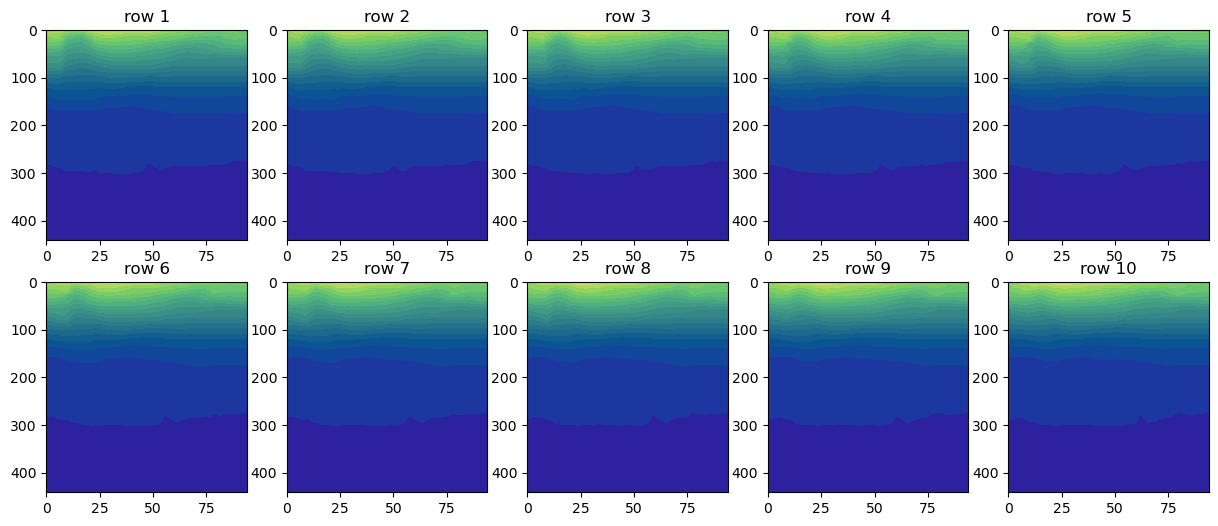

In [92]:
vmin, vmax = 30,34.5
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = original_interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

In [ ]:
# bring in water mass fraction data
floop = pd.read_csv('./output/inflowfraction_D_loop.csv').drop(columns=['Unnamed: 0'])
ffresh = pd.read_csv('./output/inflowfraction_D_fresh.csv').drop(columns=['Unnamed: 0'])
fsouth = pd.read_csv('./output/inflowfraction_D_south.csv').drop(columns=['Unnamed: 0'])
fcuc = pd.read_csv('./output/inflowfraction_D_cuc.csv').drop(columns=['Unnamed: 0'])
foffD = pd.read_csv('./output/inflowfraction_D_offD.csv').drop(columns=['Unnamed: 0'])
foffS = pd.read_csv('./output/inflowfraction_D_offS.csv').drop(columns=['Unnamed: 0'])
fnorth = pd.read_csv('./output/inflowfraction_D_north.csv').drop(columns=['Unnamed: 0'])

In [7]:
# get depth fraction profile of a certain water mass on a specific day 
def get_depth_profile(df, date_str):
    row = df.loc[df["day"] == date_str]
    prof = row.select_dtypes(include=np.number).to_numpy().squeeze()
    return prof  # shape (40,)

In [89]:
# lets hypothetically say that we think the salinity of south water and the CUC are gonna increase by 0.2 g/kg
# and that the salinity of offS water will decrease by 0.3 g/kg

date_str = '2018-01-01'
south_prof = get_depth_profile(fsouth, date_str)
cuc_prof   = get_depth_profile(fcuc, date_str)
offS_prof  = get_depth_profile(foffS, date_str)

# edit salinity, keep same 3-D array shape (depth, yb, xbT)
for k in range(interps["salt"].shape[0]):
    delta_s = (
        south_prof[k] * 0.2
        + cuc_prof[k] * 0.2
        - offS_prof[k] * 0.3
    )
    interps["salt"][k, :, :] += delta_s


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

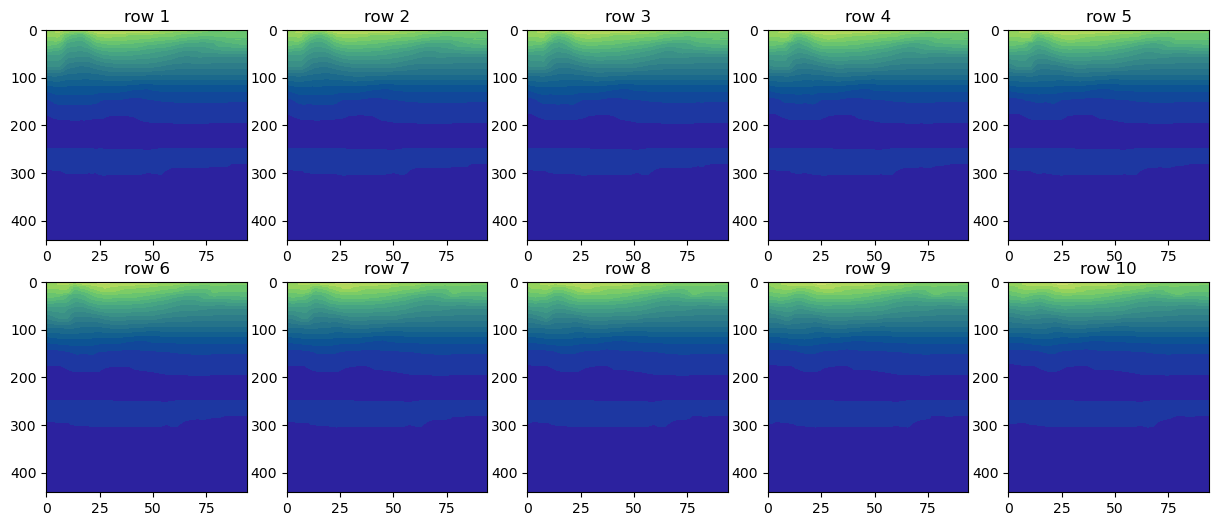

In [9]:
vmin, vmax = 30,34.5
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

# you can see here that there would be an instability introduced, look into code for checking and fixing instabilities next

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

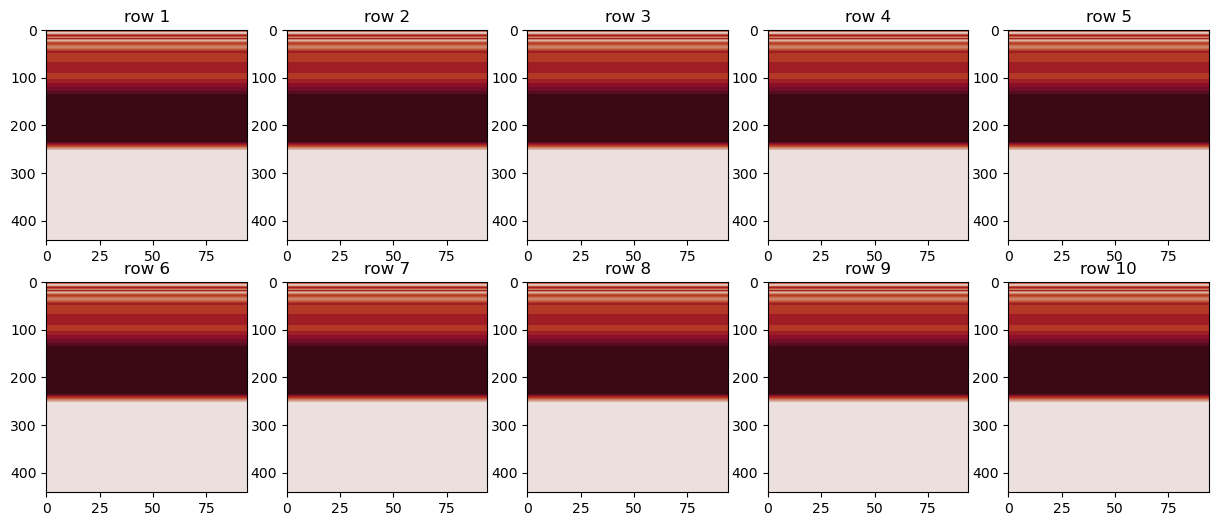

In [10]:
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = interps['salt'][:,0,95*i:95*(i+1)] - original_interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.balance,vmin=-0.1,vmax=0.1)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

## stabilize
adding salinity like we did made it such that the water ~280 m is lighter than the water above it - uh oh! <br>
let's try to bring in some of stabilization functions that Susan has for the actual making of the BC files here <br>

In [11]:
# start by applying convect
# this function simply convects vertically based on the density of cells on top of eachother
sigma = gsw.sigma0(interps['salt'], interps['temp']) # need density first
sigma, interps = convect(sigma, interps)

# stabilize (small changes to salinity to stabilize marginally stable cells)
interps = stabilize(sigma, interps)

In [12]:
# diagnostic: minimum density difference between adjacent levels
dsig = np.diff(sigma, axis=0)
print("Minimum sigma0 difference after stabilize:", np.nanmin(dsig)) # if negative then something wrong

Minimum sigma0 difference after stabilize: 0.0


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

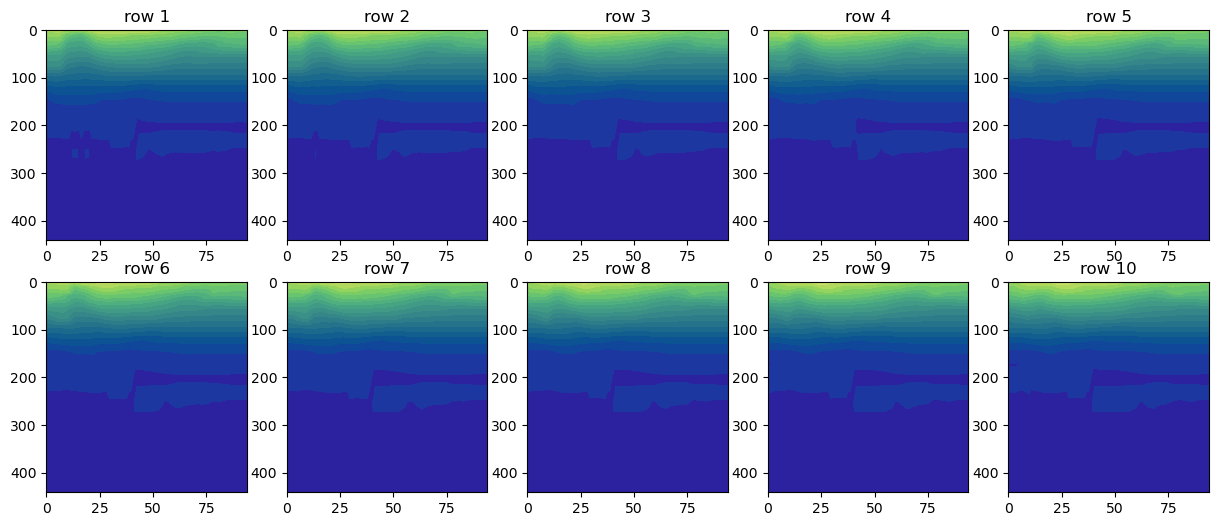

In [13]:
vmin, vmax = 30,34.5
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

## get it back into a netcdf file

In [ ]:
out = day1.copy(deep=True)

out["vosaline"][0, :, :, :] = interps["salt"]
out["votemper"][0, :, :, :] = interps["temp"]
out["NO3"][0, :, :, :]      = interps["NO3"]
out["Si"][0, :, :, :]       = interps["Si"]
out["OXY"][0, :, :, :]      = interps["oxygen"]
out["DIC"][0, :, :, :]      = interps["TIC"]
out["TA"][0, :, :, :]       = interps["alkalinity"]

# update metadata
out.attrs["history"] = out.attrs.get("history", "") + " | edited for 2100"

# save!
# out.to_netcdf("./LiveOcean_v201905_y2018m01d01_modified.nc")#, encoding=encoding)

In [15]:
test = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/LiveOcean_v201905_y2018m01d01_modified.nc')
test

<xarray.Dataset> Size: 2MB
Dimensions:       (time_counter: 1, deptht: 40, yb: 1, xbT: 950)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2018-01-01T12:00:00
  * deptht        (deptht) float64 320B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
  * yb            (yb) int64 8B 1
  * xbT           (xbT) int64 8kB 0 1 2 3 4 5 6 ... 943 944 945 946 947 948 949
Data variables:
    vosaline      (time_counter, deptht, yb, xbT) float64 304kB ...
    votemper      (time_counter, deptht, yb, xbT) float64 304kB ...
    NO3           (time_counter, deptht, yb, xbT) float64 304kB ...
    Si            (time_counter, deptht, yb, xbT) float64 304kB ...
    OXY           (time_counter, deptht, yb, xbT) float64 304kB ...
    DIC           (time_counter, deptht, yb, xbT) float64 304kB ...
    TA            (time_counter, deptht, yb, xbT) float64 304kB ...
Attributes:
    acknowledgements:      Live Ocean http://faculty.washington.edu/pmacc/LO/...
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          Salish Sea MEOPAR Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    summary:               Temperature, Salinity, Nitrate, Oxygen, DIC and TA...
    source:                http://nbviewer.jupyter.org/urls/bitbucket.org/sal...
    history:               [2019-06-10] File creation. | edited for 2100 unde...

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

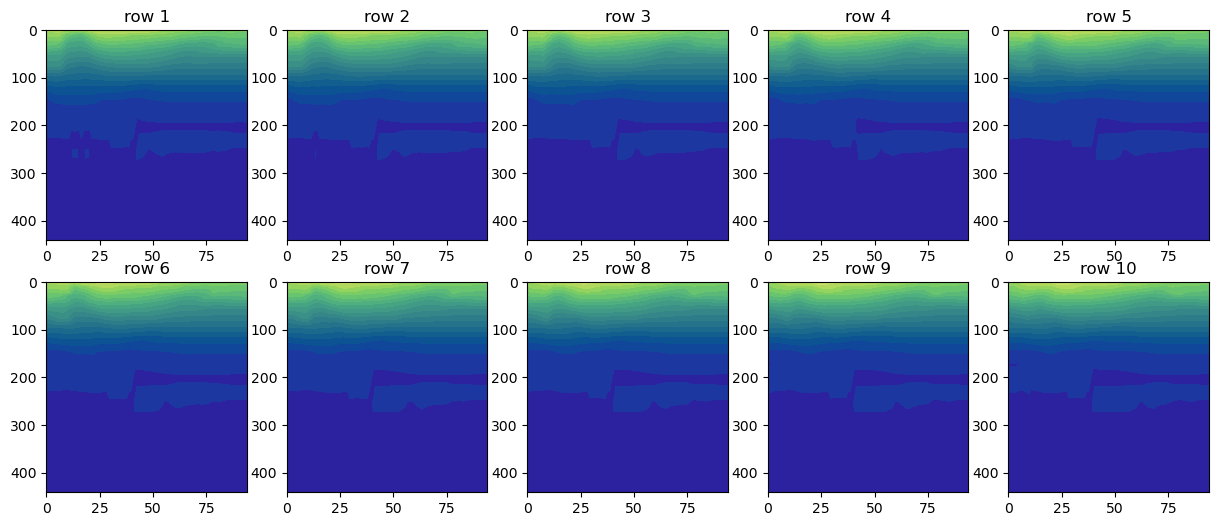

In [16]:
# build an easily editable tracer dictionary 
test_interps = {
    "salt":       test["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       test["votemper"][0, :, :, :].values.copy(),
    "NO3":        test["NO3"][0, :, :, :].values.copy(),
    "Si":         test["Si"][0, :, :, :].values.copy(),
    "oxygen":     test["OXY"][0, :, :, :].values.copy(),
    "TIC":        test["DIC"][0, :, :, :].values.copy(),
    "alkalinity": test["TA"][0, :, :, :].values.copy(),
}

vmin, vmax = 30,34.5
X, Y = np.meshgrid(test.xbT[0:95].values,test.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = test_interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

# testing real boundary decisions

In [22]:
# oxygen units in Siedlecki et al. (2021) don't align with those in SalishSeaCast
# NO3, TA, DIC in mmol/m3, no conversion necessary bc this is equivalent to uM
# must convert ml/L to uM

def oxygen_mlL_to_uM(oxygen_mlL):
    """
    Convert dissolved oxygen from mL/L to uM using molar volume.
    """

    # in seawater the 1 ml/L of oxygen is approximately equal to 44.66 umol/L
    # this is based on the molar volume of an ideal gas as STP of 22.39 L/mol
    C = 44.66
    
    # Convert mL/L to µmol/L using the in-situ molar volume
    uM = oxygen_mlL * C
    
    return uM

## south source water change only

In [32]:
# make a new copy of the boundary file
interps = {k: v.copy() for k, v in original_interps.items()}

In [33]:
# apply changes to properties
# for this case we are only changing CUC and south shelf properties

date_str = '2018-01-01'
south_prof = get_depth_profile(fsouth, date_str)
cuc_prof   = get_depth_profile(fcuc, date_str)

# edit temperature
for k in range(interps["temp"].shape[0]):
    delta = (
        south_prof[k] * 1.75
        + cuc_prof[k] * 1.03
    )
    interps["temp"][k, :, :] += delta

# edit oxygen, remember unit conversion
for k in range(interps["oxygen"].shape[0]):
    delta = (
        south_prof[k] * oxygen_mlL_to_uM(-0.28)
        + cuc_prof[k] * oxygen_mlL_to_uM(-0.3)
    )
    interps["oxygen"][k, :, :] += delta

# edit TA
for k in range(interps["alkalinity"].shape[0]):
    delta = (
        south_prof[k] * -4.17
        + cuc_prof[k] * -0.83
    )
    interps["alkalinity"][k, :, :] += delta

# edit DIC
for k in range(interps["TIC"].shape[0]):
    delta = (
        south_prof[k] * 5
        + cuc_prof[k] * 38.83
    )
    interps["TIC"][k, :, :] += delta

# edit NO3
for k in range(interps["NO3"].shape[0]):
    delta = (
        south_prof[k] * 0.84
        + cuc_prof[k] * 0.46
    )
    interps["NO3"][k, :, :] += delta

In [35]:
# STABILIZE 

# start by applying convect
# this function simply convects vertically based on the density of cells on top of eachother
sigma = gsw.sigma0(interps['salt'], interps['temp']) # need density first
sigma, interps = convect(sigma, interps)

# stabilize (small changes to salinity to stabilize marginally stable cells)
interps = stabilize(sigma, interps)

In [36]:
# diagnostic: minimum density difference between adjacent levels
dsig = np.diff(sigma, axis=0)
print("Minimum sigma0 difference after stabilize:", np.nanmin(dsig)) # if negative then something wrong

Minimum sigma0 difference after stabilize: 0.0


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

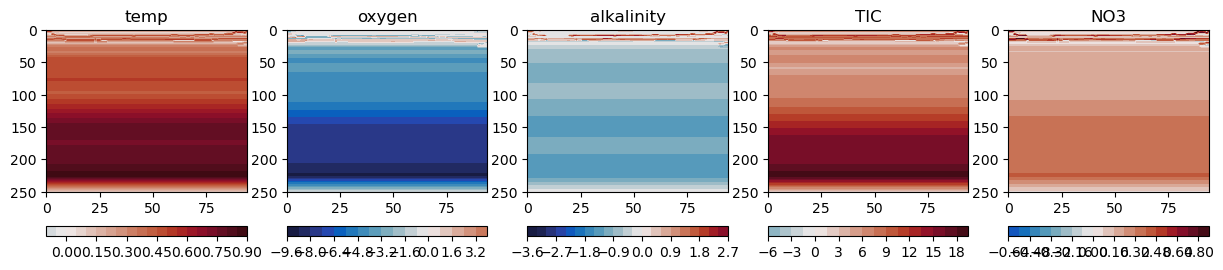

In [ ]:
# looks at a section for each edited variable
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)
tracers = ['temp','oxygen','alkalinity','TIC','NO3']

fig, ax = plt.subplots(1,5,figsize=[15,3])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = interps[tracers[i]][:,0,0:95] - original_interps[tracers[i]][:,0,0:95]
    vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# note that increasing oxygen and alkalinity near the surface (despite both changes being negative) are because of the convect step

## north/west source water change only

In [38]:
# make a new copy of the boundary file
interps = {k: v.copy() for k, v in original_interps.items()}

In [41]:
# apply changes to properties
# for this case we are only changing CUC, north shelf, and CC properties

date_str = '2018-01-01'
north_prof = get_depth_profile(fnorth, date_str)
offD_prof = get_depth_profile(foffD, date_str)
cuc_prof   = get_depth_profile(fcuc, date_str)

# edit temperature
for k in range(interps["temp"].shape[0]):
    delta = (
        north_prof[k] * 1.75
        + offD_prof[k] * 2.05
        + cuc_prof[k] * (2.05*0.7)
    )
    interps["temp"][k, :, :] += delta

# edit oxygen, remember unit conversion
for k in range(interps["oxygen"].shape[0]):
    delta = (
        north_prof[k] * oxygen_mlL_to_uM(-0.28)
        + offD_prof[k] * oxygen_mlL_to_uM(-0.6)
        + cuc_prof[k] * oxygen_mlL_to_uM((-0.6*0.7))
    )
    interps["oxygen"][k, :, :] += delta

# edit TA
for k in range(interps["alkalinity"].shape[0]):
    delta = (
        north_prof[k] * -4.17
        + offD_prof[k] * -1.66
        + cuc_prof[k] * (-1.66*0.7)
    )
    interps["alkalinity"][k, :, :] += delta

# edit DIC
for k in range(interps["TIC"].shape[0]):
    delta = (
        north_prof[k] * 5
        + offD_prof[k] * 77.66
        + cuc_prof[k] * (77.66*0.7)
    )
    interps["TIC"][k, :, :] += delta

# edit NO3
for k in range(interps["NO3"].shape[0]):
    delta = (
        north_prof[k] * 0.84
        + offD_prof[k] * 0.91
        + cuc_prof[k] * (0.91*0.7)
    )
    interps["NO3"][k, :, :] += delta

In [42]:
# STABILIZE 

# start by applying convect
# this function simply convects vertically based on the density of cells on top of eachother
sigma = gsw.sigma0(interps['salt'], interps['temp']) # need density first
sigma, interps = convect(sigma, interps)

# stabilize (small changes to salinity to stabilize marginally stable cells)
interps = stabilize(sigma, interps)

In [43]:
# diagnostic: minimum density difference between adjacent levels
dsig = np.diff(sigma, axis=0)
print("Minimum sigma0 difference after stabilize:", np.nanmin(dsig)) # if negative then something wrong

Minimum sigma0 difference after stabilize: 0.0


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

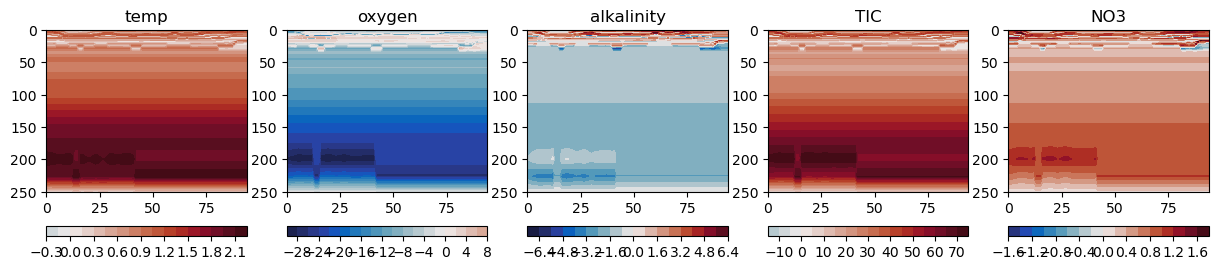

In [44]:
# looks at a section for each edited variable
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)
tracers = ['temp','oxygen','alkalinity','TIC','NO3']

fig, ax = plt.subplots(1,5,figsize=[15,3])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = interps[tracers[i]][:,0,0:95] - original_interps[tracers[i]][:,0,0:95]
    vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# note that increasing oxygen and alkalinity near the surface (despite both changes being negative) are because of the convect step

## Upwelling

In [73]:
date_str = '2018-01-01'
north_prof = get_depth_profile(fnorth, date_str)
south_prof = get_depth_profile(fsouth, date_str)
cuc_prof   = get_depth_profile(fcuc, date_str)

In [74]:
# get the mean upwelling period property differences from your lagrangian results
S_diff_south = 33.90-32.97       # mean salinity difference between CUC and south shelf, g/kg
S_diff_north = 33.90-33.24       # mean salinity difference between CUC and north shelf, g/kg

T_diff_south = 6.25-8.92         # mean temperature difference between CUC and south shelf, degC
T_diff_north = 6.25-7.55         # mean temperature difference between CUC and north shelf, degC

O_diff_south = 62.26-200.76      # mean oxygen difference between CUC and south shelf, umol/kg
O_diff_north = 62.26-153.26      # mean oxygen difference between CUC and north shelf, umol/kg

TA_diff_south = 2262-2218        # mean alkalinity difference between CUC and south shelf, umol/kg
TA_diff_north = 2262-2227        # mean alkalinity difference between CUC and north shelf, umol/kg

DIC_diff_south = 2263-2124       # mean DIC difference between CUC and south shelf, umol/kg
DIC_diff_north = 2263-2167       # mean DIC difference between CUC and north shelf, umol/kg

N_diff_south = 37.27-19.09       # mean NO3 difference between CUC and south shelf, mmol/m3
N_diff_north = 37.27-24.26       # mean NO3 difference between CUC and north shelf, mmol/m3

In [75]:
# differences in units of umol/kg must be converted to uM to match the boundary condition files
# multiply by the density (kg/m3) and devide by 1000 (1000 L per m3)
# use the mean S and T from the two water masses, and take depth as 150 m because that's approximately where the mixing between the two will occur
rho = gsw.rho(np.mean([33.90,32.97,33.24]), np.mean([6.25,8.92,7.55]), 150) # kg/m3

O_diff_south = O_diff_south*rho/1000
O_diff_north = O_diff_north*rho/1000

TA_diff_south = TA_diff_south*rho/1000
TA_diff_north = TA_diff_north*rho/1000

DIC_diff_south = DIC_diff_south*rho/1000
DIC_diff_north = DIC_diff_north*rho/1000

In [76]:
# make a new copy of the boundary file
interps = {k: v.copy() for k, v in original_interps.items()}

frac_change = -0.21      # +ve means more CUC; -ve means less CUC

requested_delta_f = frac_change * cuc_prof

# If CUC increases, cap transfer by available shelf water.
# If CUC decreases, cap transfer by available CUC water.
if np.sum(south_prof)>np.sum(north_prof):
    delta_f = np.where(
        requested_delta_f >= 0,
        np.minimum(requested_delta_f, south_prof),
        np.maximum(requested_delta_f, -cuc_prof),
    )

    delta_S_profile = delta_f * S_diff_south
    delta_T_profile = delta_f * T_diff_south
    delta_O_profile = delta_f * O_diff_south
    delta_TA_profile = delta_f * TA_diff_south
    delta_DIC_profile = delta_f * DIC_diff_south
    delta_N_profile = delta_f * N_diff_south

else:
    delta_f = np.where(
        requested_delta_f >= 0,
        np.minimum(requested_delta_f, north_prof),
        np.maximum(requested_delta_f, -cuc_prof),
    )

    delta_S_profile = delta_f * S_diff_north
    delta_T_profile = delta_f * T_diff_north
    delta_O_profile = delta_f * O_diff_north
    delta_TA_profile = delta_f * TA_diff_north
    delta_DIC_profile = delta_f * DIC_diff_north
    delta_N_profile = delta_f * N_diff_north

interps["salt"] += delta_S_profile[:, None, None]
interps["temp"] += delta_T_profile[:, None, None]
interps["oxygen"] += delta_O_profile[:, None, None]
interps["alkalinity"] += delta_TA_profile[:, None, None]
interps["TIC"] += delta_DIC_profile[:, None, None]
interps["NO3"] += delta_N_profile[:, None, None]


In [77]:
# STABILIZE 

# start by applying convect
# this function simply convects vertically based on the density of cells on top of eachother
sigma = gsw.sigma0(interps['salt'], interps['temp']) # need density first
sigma, interps = convect(sigma, interps)

# stabilize (small changes to salinity to stabilize marginally stable cells)
interps = stabilize(sigma, interps)

In [78]:
# diagnostic: minimum density difference between adjacent levels
dsig = np.diff(sigma, axis=0)
print("Minimum sigma0 difference after stabilize:", np.nanmin(dsig)) # if negative then something wrong

Minimum sigma0 difference after stabilize: 0.0


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

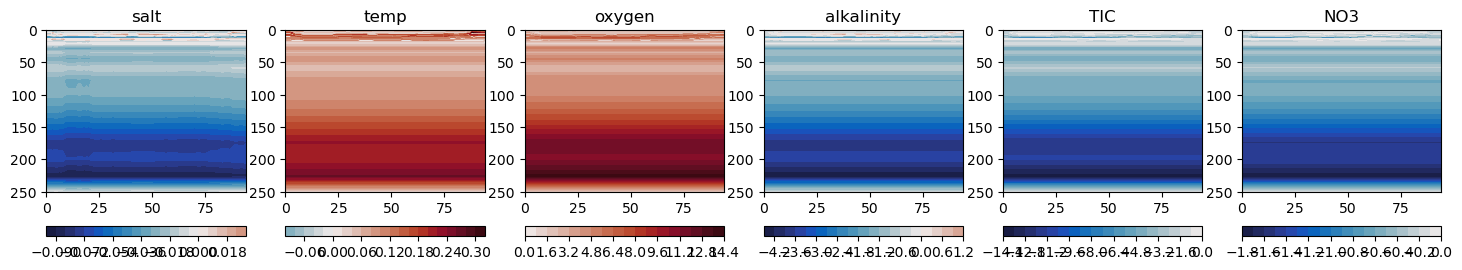

In [ ]:
# looks at a section for each edited variable
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)
tracers = ['salt','temp','oxygen','alkalinity','TIC','NO3']

fig, ax = plt.subplots(1,6,figsize=[18,3])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = interps[tracers[i]][:,0,0:95] - original_interps[tracers[i]][:,0,0:95]
    vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# goes in the direction that we'd expect!